In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#defining file path
file_location = r"C:\Users\hp\Downloads\Data1.xlsx"
df = pd.read_excel(file_location, sheet_name="Sheet1")
print(f"Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}")
df.head()

Total Rows: 1200, Total Columns: 14


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [ ]:
print("Basic Descriptive Statistics")
numeric_summary = df[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']].describe()
print(numeric_summary)
print("\nProduct Performance Summary (Revenue & Volume)")
product_perf = df.groupby('Product').agg(
    Total_Quantity=('Quantity', 'sum'),
    Total_Revenue=('TotalPrice', 'sum'),
    Average_UnitPrice=('UnitPrice', 'mean')
).reset_index().sort_values(by='Total_Revenue', ascending=False)
product_perf

Basic Descriptive Statistics
          Quantity    UnitPrice  ItemsInCart   TotalPrice
count  1200.000000  1200.000000  1200.000000  1200.000000
mean      2.945833   356.412750     5.485000  1053.968300
std       1.407557   197.177146     2.281983   819.856558
min       1.000000    11.390000     1.000000    11.390000
25%       2.000000   186.062500     4.000000   410.520000
50%       3.000000   364.210000     5.000000   823.615000
75%       4.000000   521.570000     7.000000  1578.475000
max       5.000000   699.930000    10.000000  3456.400000

Product Performance Summary (Revenue & Volume)


,Product,Total_Quantity,Total_Revenue,Average_UnitPrice
0,Chair,562,195620.11,355.660281
5,Printer,542,195612.61,351.714917
2,Laptop,535,192126.56,357.707052
6,Tablet,497,186568.95,367.679106
3,Monitor,480,175651.41,358.663620
1,Desk,508,167459.93,329.608118
4,Phone,411,151722.39,375.217564


 Outlier Detection (Forensic Scan) 
Total Extreme Outliers Found: 8


C:\Users\hp\AppData\Local\Temp\ipykernel_13168\1254028716.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=product_perf, x='Product', y='Total_Revenue', palette='Blues_r')


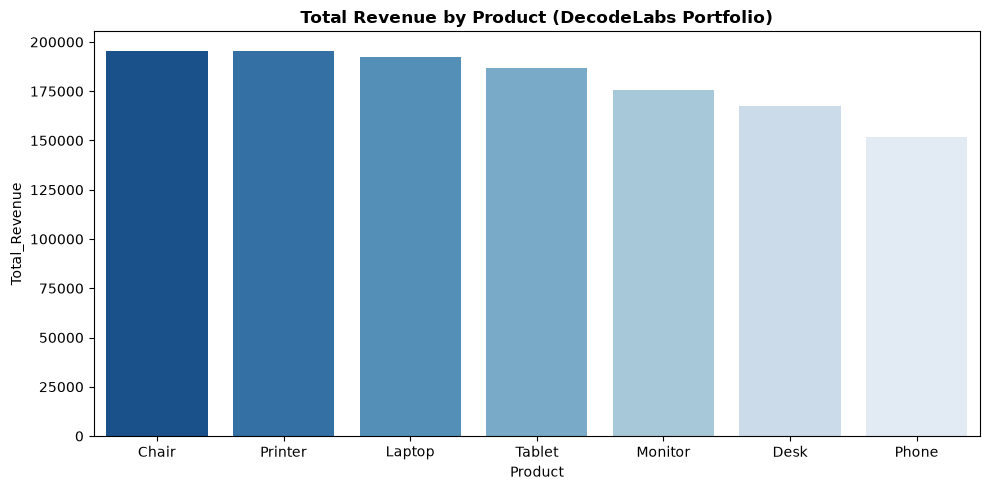

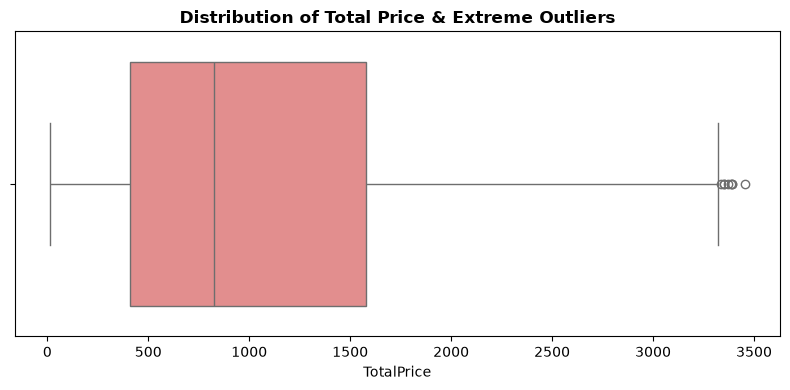

,OrderID,Product,Quantity,UnitPrice,TotalPrice
107,ORD200107,Printer,5,670.75,3353.75
326,ORD200326,Laptop,5,670.48,3352.40
328,ORD200328,Tablet,5,674.04,3370.20
469,ORD200469,Chair,5,676.98,3384.90
632,ORD200632,Laptop,5,678.16,3390.80
789,ORD200789,Tablet,5,691.28,3456.40
1065,ORD201065,Printer,5,666.80,3334.00
1122,ORD201122,Monitor,5,678.19,3390.95


In [5]:
print(" Outlier Detection (Forensic Scan) ")
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['TotalPrice'] < lower_bound) | (df['TotalPrice'] > upper_bound)]
print(f"Total Extreme Outliers Found: {len(outliers)}")
#pictorial representataion
plt.figure(figsize=(10, 5))
sns.barplot(data=product_perf, x='Product', y='Total_Revenue', palette='Blues_r')
plt.title('Total Revenue by Product (DecodeLabs Portfolio)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('product_revenue_chart.png', dpi=300)
plt.show()
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['TotalPrice'], color='lightcoral')
plt.title('Distribution of Total Price & Extreme Outliers', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('outliers_boxplot.png', dpi=300)
plt.show()
outliers[['OrderID', 'Product', 'Quantity', 'UnitPrice', 'TotalPrice']]